# **METRICAS**

Apellido y Nombre: Vasquez Caiza Juan Marcelo.

Carrera: Ingenieria de Sistemas.

In [33]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score

import torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms

from torch.utils.data import random_split

# **Preparacion de datos**

In [34]:
IMG_SIZE = 32
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize(IMG_SIZE), 
    transforms.CenterCrop(IMG_SIZE), 
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

In [35]:
train_root_dir = 'C:/Users/asus/Documents/SIS420-Inteligencia-Artificial-I-/Laboratorios/Laboratorio6/train'
val_root_dir = 'C:/Users/asus/Documents/SIS420-Inteligencia-Artificial-I-/Laboratorios/Laboratorio6/val'

In [36]:
trainset = ImageFolder(root=train_root_dir, transform=transform)
valset = ImageFolder(root=val_root_dir, transform=transform)

classes = trainset.classes

In [37]:
print(f"Clases detectadas: {classes}")
print(f"Imágenes de entrenamiento: {len(trainset)}")
print(f"Imágenes de validación: {len(valset)}")

Clases detectadas: ['cat', 'dog', 'elephant', 'horse', 'lion']
Imágenes de entrenamiento: 13474
Imágenes de validación: 1497


In [38]:
dataloader = {
    'train': torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True),
    'val': torch.utils.data.DataLoader(valset, batch_size=555, shuffle=False)
}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3512855..1.7865399].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9131652..1.7511113].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4329139..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.2914162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.465708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.308

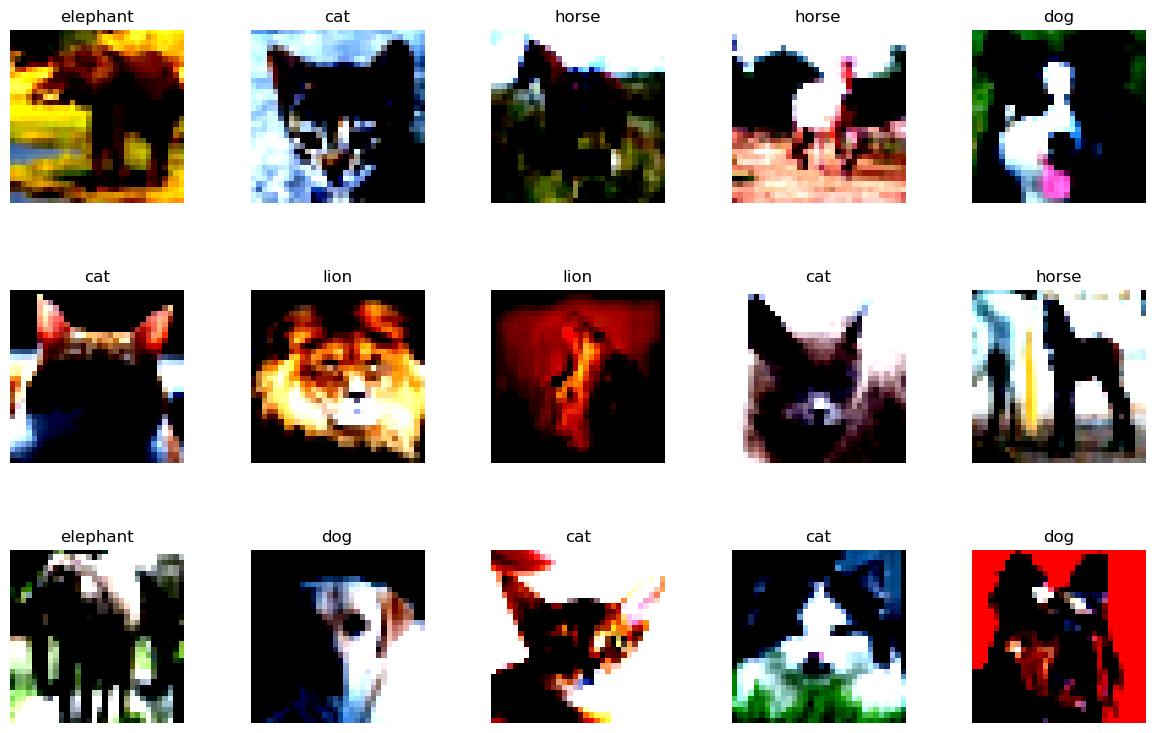

In [39]:
import random
import matplotlib.pyplot as plt

r, c = 3, 5
plt.figure(figsize=(c*3, r*3))
for row in range(r):
    for col in range(c):
        index = c*row + col
        plt.subplot(r, c, index + 1)
        ix = random.randint(0, len(trainset)-1)
        img, label = trainset[ix]

        # Reordenar las dimensiones del tensor para que imshow pueda mostrar la imagen
        img = img.permute(1, 2, 0)
        
        # Opcional: convertir el tensor a NumPy para asegurar compatibilidad
        img = img.cpu().numpy()

        plt.imshow(img)
        plt.axis('off')
        plt.title(classes[label])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

# **Entrenando un clasificador binario**

In [40]:
import torch.nn as nn

class Perceptron(nn.Module):
    def __init__(self, input_size):
        super(Perceptron, self).__init__()
        self.fc = nn.Linear(input_size, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [41]:
import torch.optim as optim

input_size = 32 * 32 * 3


model = Perceptron(input_size)


criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-5)

Bucle de Entrenamiento:

In [ ]:
epochs = 10

class_to_idx = {cls: i for i, cls in enumerate(classes)}
cat_idx = class_to_idx['cat']

for epoch in range(epochs):
    # FASE DE ENTRENAMIENTO
    model.train()
    running_loss = 0.0
    for images, labels in dataloader['train']:
        
        binary_labels = (labels == cat_idx).float().unsqueeze(1)
        
        
        optimizer.zero_grad()
        
        
        outputs = model(images)
        
        
        loss = criterion(outputs, binary_labels)
        
        
        loss.backward()
        
        
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)

    # FASE DE VALIDACIÓN
    model.eval() 
    val_loss = 0.0
    with torch.no_grad(): 
        for images, labels in dataloader['val']:
            binary_labels = (labels == cat_idx).float().unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, binary_labels)
            val_loss += loss.item() * images.size(0)
    
    epoch_loss = running_loss / len(trainset)
    val_epoch_loss = val_loss / len(valset)

    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}')

print("Entrenamiento finalizado.")

Epoch 1/10, Loss: 0.7113, Val Loss: 0.6970
Epoch 2/10, Loss: 0.6751, Val Loss: 0.6724
Epoch 3/10, Loss: 0.6527, Val Loss: 0.6572
Epoch 4/10, Loss: 0.6376, Val Loss: 0.6468
Epoch 5/10, Loss: 0.6265, Val Loss: 0.6389
Epoch 6/10, Loss: 0.6178, Val Loss: 0.6326
Epoch 7/10, Loss: 0.6106, Val Loss: 0.6273
Epoch 8/10, Loss: 0.6045, Val Loss: 0.6226
Epoch 9/10, Loss: 0.5991, Val Loss: 0.6184
Epoch 10/10, Loss: 0.5944, Val Loss: 0.6145
Entrenamiento finalizado.


# **Realizamos Predicciones**

In [ ]:
from sklearn.metrics import confusion_matrix

model.eval()


with torch.no_grad():
    all_preds = []
    all_labels = []
    
    
    for images, labels in dataloader['val']:
        
        binary_labels = (labels == cat_idx).float().unsqueeze(1)
        
        
        outputs = model(images)
        
        
        preds = (torch.sigmoid(outputs) > 0.5).int()
        
        
        all_preds.extend(preds.view(-1).cpu().numpy())
        all_labels.extend(binary_labels.view(-1).cpu().numpy())


accuracy = accuracy_score(all_labels, all_preds)


conf_matrix = confusion_matrix(all_labels, all_preds)

print(f"Precisión del modelo en el conjunto de validación: {accuracy:.4f}")
print("\nMatriz de Confusión:")
print(conf_matrix)

Precisión del modelo en el conjunto de validación: 0.6633

Matriz de Confusión:
[[847 350]
 [154 146]]


# **Accuracy**

In [44]:
all_labels_M = np.array(all_labels)
all_preds_M = np.array(all_preds)

def accuracyManual(y_pred, y):
    return np.sum(y_pred == y) / len(y)

In [45]:
accuracy_manual_val = accuracyManual(all_preds_M, all_labels_M)
print(f"Precisión del modelo en el conjunto de validación de forma Manual: {accuracy_manual_val:.4f}")

Precisión del modelo en el conjunto de validación de forma Manual: 0.6633


# **Matriz de Confusión**

In [46]:
TP = np.sum((all_preds_M == 1) & (all_labels_M == 1)) 
TN = np.sum((all_preds_M == 0) & (all_labels_M == 0)) 
FP = np.sum((all_preds_M == 1) & (all_labels_M == 0))
FN = np.sum((all_preds_M == 0) & (all_labels_M == 1))

CM = [[TN, FP],
      [FN, TP]]

print("Matriz de Confusión realizada de forma Manual:")
print(f"[[{TN:d},{FP:d}],[{FN:d},{TP:d}]]")

Matriz de Confusión realizada de forma Manual:
[[847,350],[154,146]]


# **Precision y Recall**

In [47]:
def precisionManual(y_pred, y):
    TP = np.sum((y_pred == 1) & (y == 1)) 
    FP = np.sum((y_pred == 1) & (y == 0))
    return TP / (TP + FP)

def recallManual(y_pred, y):
    TP = np.sum((y_pred == 1) & (y == 1)) 
    FN = np.sum((y_pred == 0) & (y == 1))
    return TP / (TP + FN)

In [48]:
preM, recM =precisionManual(all_preds_M,all_labels_M), recallManual(all_preds_M,all_labels_M)
print("Precision y Recall Calculados manualmente:")
print(f"({preM},{recM})")

Precision y Recall Calculados manualmente:
(0.29435483870967744,0.4866666666666667)


In [49]:
from sklearn.metrics import precision_score, recall_score

precision_score(all_labels, all_preds), recall_score(all_labels, all_preds)

(0.29435483870967744, 0.4866666666666667)

# **F1-Score**

In [50]:
p = precision_score(all_labels_M, all_preds_M)
r = recall_score(all_labels_M, all_preds_M)
f1 = 2*(p*r)/(p+r)
print(f"F1-Score Manualmente: {f1}")

F1-Score Manualmente: 0.36683417085427145


In [51]:
from sklearn.metrics import f1_score

f1_score(all_labels, all_preds)

0.36683417085427134

# **La curva ROC**

In [52]:
model.eval() 
all_probs = [] 
all_labels_roc = []

with torch.no_grad():
    for images, labels in dataloader['val']:
        
        binary_labels = (labels == cat_idx).float().unsqueeze(1)
        
        
        outputs = model(images)
        
        
        probs = torch.sigmoid(outputs)
        
        
        all_probs.extend(probs.view(-1).cpu().numpy())
        all_labels_roc.extend(binary_labels.view(-1).cpu().numpy())

all_probs = np.array(all_probs)
all_labels_roc = np.array(all_labels_roc)

In [53]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(all_labels_roc, all_probs)

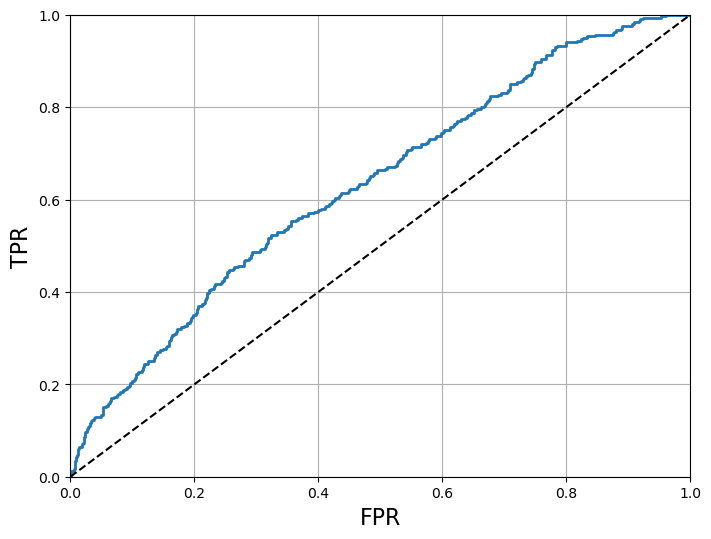

In [54]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.axis([0, 1, 0, 1])                                    
    plt.xlabel('FPR', fontsize=16) 
    plt.ylabel('TPR', fontsize=16)    
    plt.grid(True)                                            

plt.figure(figsize=(8, 6))                         
plot_roc_curve(fpr, tpr)              
plt.show()

In [55]:
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(all_labels_roc, all_probs)
print(f"Resultado AUC (Área Bajo la Curva): {auc_score:.4f}")

Resultado AUC (Área Bajo la Curva): 0.6321
